<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Métodos Numéricos
        </td>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 20 - Método de Traub
        </td>
    </tr>
    <tr>
 

</table>

In [89]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Método de Traub

In [90]:
def Traub(f,df,x0,tol,maxiter):
    iters = 0
    error = tol + 1

    while iters <= maxiter and error > tol:
        y = x0-f(x0)/df(x0)
        x = y-f(y)/df(x0)
        error = math.fabs(x-x0)
        iters += 1
        x0 = x
    return [x,iters, error]

# Método de Traub con ACOC

In [91]:
def TraubACOC(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    error_x = list()

    while error>tol and iters<=maxiter:
       
        y = x0-f(x0)/df(x0)
        x = y-f(y)/df(x0)
        error = math.fabs(x-x0)
        error_x.append(error)
        iters = iters+1
        x0 = x

    error_x = np.array(error_x)
    ACOC = np.log(error_x[2:]/error_x[1:-1])/np.log(error_x[1:-1]/error_x[0:-2])
    
    return [x,iters,error,ACOC]

# Tabla método de Traub

In [92]:
def Traubtabla(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    lista_x = list(); lista_e = list() #Se crean listas para x y el error

    while error>tol and iters<=maxiter:
        y = x0-f(x0)/df(x0)
        x = y-f(y)/df(x0)
        error = math.fabs(x-x0)
        iters = iters+1
        x0 = x
        lista_x.append(x); lista_e.append(error);
    tabla = pd.DataFrame({'Iteraciones': lista_x, 'Error': lista_e}) #Se crear el dataframe
    pd.set_option('display.precision', 12)
    return tabla

# Ejemplo 1

Resolver $x^5-3x+1=0$ con una tolerancia de $10^{-10}$ y una estimación de $x_0=1$

In [93]:
#definir f = x^5-3x+1=0
f = lambda x: x**5-3*x+1

# Derivada df = 5x^4-3
df = lambda x: 5*x**4-3

tol = 1e-10
x0 = 1
maxiter = 30

x, iters, error = Traub(f, df, x0,tol,maxiter)


print(f"La solución a la ecuación es x = {x}")
print("El número de iteraciones fue de %s" %iters)
print("El error que se tuvo fue %s" %error)

La solución a la ecuación es x = 0.3347341419433527
El número de iteraciones fue de 5
El error que se tuvo fue 5.551115123125783e-17


In [94]:
Traubtabla(f, df, x0,tol,maxiter)

,Iteraciones,Error
0,-0.546875000000,1.546875000000e+00
1,0.318505242078,8.653802420779e-01
2,0.334734025500,1.622878342214e-02
3,0.334734141943,1.164433022782e-07
4,0.334734141943,5.551115123126e-17


# Ejemplo 2

Resolver la ecuación $e^{-x^2}-\cos(x)=0$, usando una tolerancia de $10^{-10}$ y una estimación de $x_0=1$. Obtener el ACOC

$f(x)=e^{-x^2}-\cos(x)  \quad \quad f'(x)=-2xe^{-x^2}+\sin(x)$

In [95]:
f = lambda x: math.exp(-x**2)-math.cos(x)

df = lambda x: -2*x*math.exp(-x**2)+math.sin(x)

x0 = 2

tol = 1e-6
maxiter=30


x,iters,error,ACOC = TraubACOC(f,df,x0,tol,maxiter)

print(f"La solución a la ecuación es x = {x}")
print(f"El número de iteraciones fue de {iters}")
print(f"El error que se tuvo fue {error}")
print(f"El vector del ACOC es {ACOC}")


La solución a la ecuación es x = 1.4474142712962368
El número de iteraciones fue de 3
El error que se tuvo fue 3.799837979823195e-07
El vector del ACOC es [2.28606906]


# Ejemplo 3

Resolver $8x-\cos(x)-2x^2=0$.

a) Realizar una representación gráfica de la función para determinar las estimaciones iniciales.

b) Resolver la ecuación con el Método de Traub y una tolerancia de $10^{-8}$

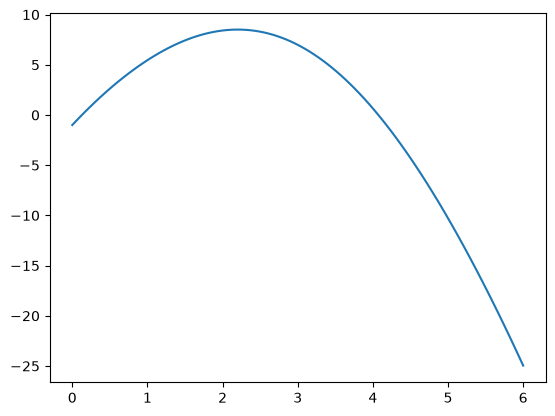

In [96]:
x = np.linspace(0,6,100)

y = 8*x-np.cos(x)-2*x**2

plt.figure()
plt.plot(x,y)
plt.show()

# Las estimaciones iniciales son x0=0 y x0=4

### ACOC (Approximated Computational Order of Convergence)
Es una métrica numérica utilizada en análisis numérico para estimar de forma experimental la velocidad a la que un método iterativo se aproxima a la solución de una ecuación o sistema de ecuaciones no lineales